# Preliminary Steps

We'll be using the statsmodel api for our data this week. To install the statsmodel package, activate your conda environment in your terminal and run conda install -c conda-forge statsmodels.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

Here is the dataset we'll be working with today and its details: https://www.statsmodels.org/stable/datasets/generated/fair.html

In [2]:
# load dataset
affairs = sm.datasets.fair.load_pandas().data

# add "affair" column: 1 represents having affairs, 0 represents not
affairs['affair'] = (affairs.affairs > 0).astype(int)

In [3]:
affairs

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1
...,...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000,0
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000,0
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000,0
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000,0


The goal of a logistic regression using this data is to see if we can successfully predict whether a woman will have an affair or not (which is why we created a boolean column for an affair).

# EDA

Let's check the difference in averages for those that had affairs and those that didn't. You can do this by grouping by the affairs column we made earlier and using the mean method.

In [6]:
# TODO
average_comparison = affairs.groupby("affairs").mean()
print(average_comparison)

           rate_marriage        age  yrs_married  children  religious  \
affairs                                                                 
0.000000        4.329701  28.390679     7.989335  1.238813   2.504521   
0.043478        3.681818  41.090909    23.000000  3.272727   2.409091   
0.060606        4.318182  33.363636    16.500000  2.931818   2.590909   
0.076923        3.160000  31.800000    13.000000  1.840000   2.280000   
0.111111        3.862069  29.413793     9.000000  1.655172   2.172414   
...                  ...        ...          ...       ...        ...   
25.599991       3.000000  22.000000     2.500000  0.500000   2.000000   
26.879990       3.000000  23.666667     2.500000  0.666667   1.666667   
38.399994       3.000000  27.000000     2.500000  0.000000   1.000000   
39.199982       3.000000  22.000000     0.500000  0.000000   1.000000   
57.599991       5.000000  22.000000     2.500000  1.000000   1.000000   

                educ  occupation  occupation_husb 

As we can see, those who had affairs tend to rate their marriage lower, spent longer married, etc. Make sure you understand what each value in each column means here!

Now, check the average values of each column grouped by rate_marriage.

In [11]:
# TODO
avg_marriage_rate = affairs.groupby("rate_marriage").mean()
print(avg_marriage_rate)

                     age  yrs_married  children  religious       educ  \
rate_marriage                                                           
1.0            33.823232    13.914141  2.308081   2.343434  13.848485   
2.0            30.471264    10.727011  1.735632   2.330460  13.864943   
3.0            30.008056    10.239174  1.638469   2.308157  14.001007   
4.0            28.856601     8.816905  1.369536   2.400981  14.144514   
5.0            28.574702     8.311662  1.252794   2.506334  14.399776   

               occupation  occupation_husb   affairs    affair  
rate_marriage                                                   
1.0              3.232323         3.838384  1.201671  0.747475  
2.0              3.327586         3.764368  1.615745  0.635057  
3.0              3.402820         3.798590  1.371281  0.550856  
4.0              3.420161         3.835861  0.674837  0.322926  
5.0              3.454918         3.892697  0.348174  0.181446  


You should see three variables that increase as the marriage rating declines. What are they?

Age, yrs_married, and children increases as the marriage rating declines.

# Visualizations

Out of curiosity, let's check the education level and frequency of each education level in the data.

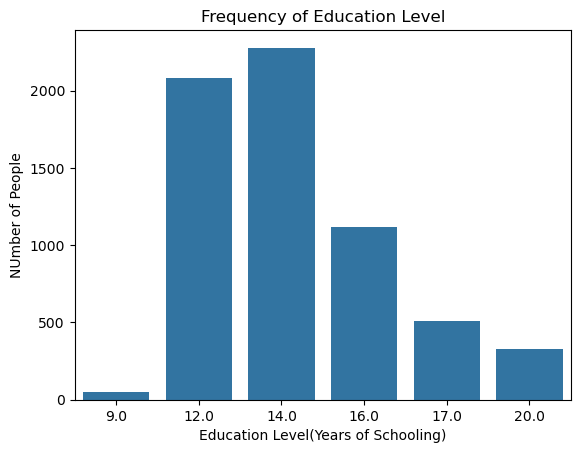

In [22]:
# TODO
import matplotlib.pyplot as plt
import seaborn as sns

education_freq= affairs["educ"].value_counts()

sns.barplot(x=education_freq.index, y=education_freq.values)
plt.xlabel("Education Level(Years of Schooling)")
plt.ylabel("NUmber of People")
plt.title("Frequency of Education Level")
plt.show()

Create another histogram for marriage rating!

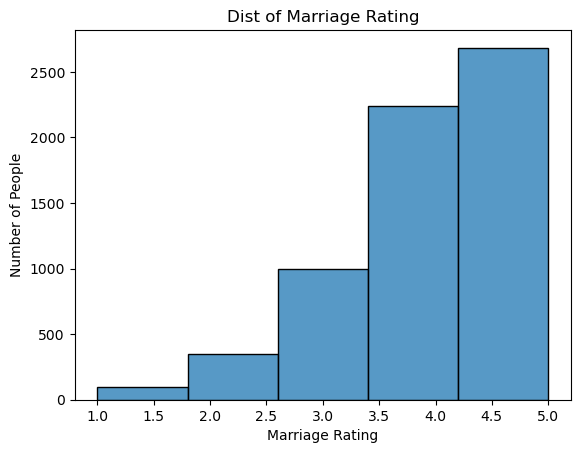

In [27]:
# TODO
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(affairs["rate_marriage"], bins=5)
plt.xlabel("Marriage Rating")
plt.ylabel("Number of People")
plt.title("Dist of Marriage Rating")
plt.show()

Let's take a look at a more useful barplot still using marriage rating (organized by whether they had an affair or not). What do we learn from this?

Text(0, 0.5, 'Frequency')

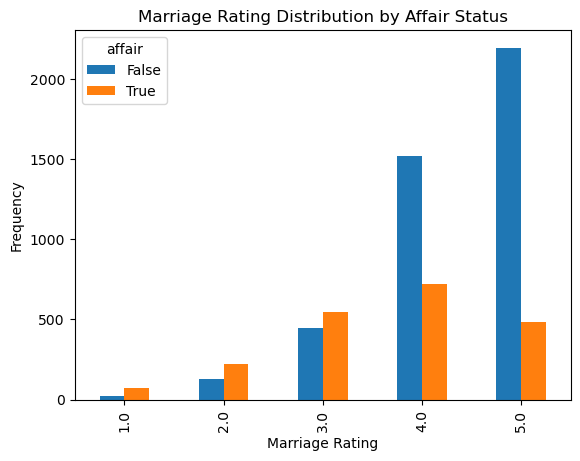

In [28]:
pd.crosstab(affairs.rate_marriage, affairs.affair.astype(bool)).plot(kind='bar')
plt.title('Marriage Rating Distribution by Affair Status')
plt.xlabel('Marriage Rating')
plt.ylabel('Frequency')

Finally, let's take a look at the percentage of people who had affairs by the number of years they were married.

Text(0, 0.5, 'Percentage')

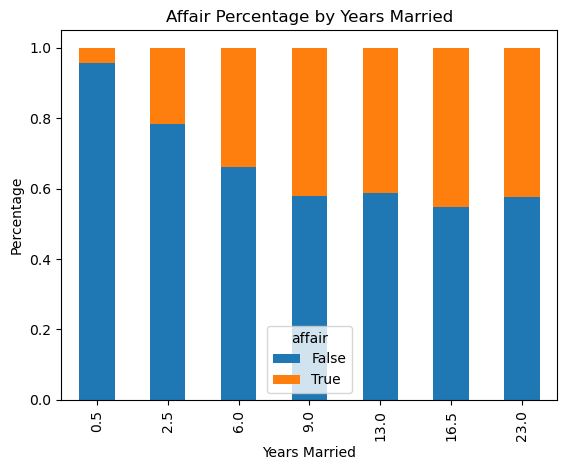

In [29]:
affair_yrs_married = pd.crosstab(affairs.yrs_married, affairs.affair.astype(bool))
affair_yrs_married.div(affair_yrs_married.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Affair Percentage by Years Married')
plt.xlabel('Years Married')
plt.ylabel('Percentage')

Interpret this graph. What does this mean/tell us?

This graph tells us the percentage that an affair would occur depending on how many years the couple has been married. Orange(True) is the percentage that an affair would occur while Blue(False) is the percentage that an affair would not occur. 

# Logistic Regression Prep

Let's import some necessary packages first. <br>
If you don't have sklearn installed, use conda install scikit-learn in your conda environment

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

We saw that occupation and occupation_husb are technically categorical variables describing the type of job each person has. We would like to include it as a predictor variable, but it would not make sense to use it in a continuous numerical variable (since each number is a category). Therefore, we must make these columns into dummy variables (if you're confused on any of this, ask us questions!)

In [33]:
affairs

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1
...,...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000,0
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000,0
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000,0
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000,0


If we try using the [get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) method on our data, we'll notice that it doesn't work as expected (dimensions of our data are the same!)

In [34]:
pd.get_dummies(affairs)

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1
...,...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000,0
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000,0
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000,0
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000,0


This is because the data in the columns we want dummies for is a float. However, pd.get_dummies automatically converts categorical variables and not quantitative variables. To fix this, turn the columns of interest into strings to make it categorical. This is called one hot encoding.

In [45]:
# Create a new dataframe called ohc_affairs (ohc stands for One Hot Encoding) where we have all the same data as before,
# but we have one hot encoded the categorical columns (read above to see which columns here are categorical)
# Use pd.get_dummies and use the documentation!
# Hint: You should have 32 columns after you do your one hot encoding
ohc_affairs = pd.get_dummies(affairs, columns=["religious", "occupation", "occupation_husb"])
print(ohc_affairs.shape)

(6366, 23)


# Logistic Regression

Now that we have our variables let's test our model before using a train/test split.

In [49]:
# TODO
y = ohc_affairs["affair"]
X = ohc_affairs.drop("affair", axis=1)

Create an sklearn LogisticRegression object and fit it to your design matrix X and your target feature y.

In [58]:
# TODO
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Find your model score using the score() method of the LogisticRegression object.

In [59]:
# TODO
accuracy = model.score(X, y)
print(accuracy)

0.978636506440465


This accuracy seems high, but we need to check something called the null error rate. The null error rate is the accuracy we would get by only guessing one type of answer (in this case, if we only guessed that a person would not have an affair).

In [60]:
# TODO
null_error_rate= y.value_counts().max()/len(y)
print(null_error_rate)

0.6775054979579014


So 32% of women had affairs, meaning 68% of women did not have affairs. Our null error rate is 68%, meaning we could guess accurately 68% of the time by only predicting that they would not have an affair. Our model is better than this rate only by a slight amount.

Let's check the coefficients of each variable to see what kind of patterns we get.

In [61]:
pd.DataFrame(zip(X.columns, np.transpose(model.coef_)))

,0,1
0,rate_marriage,[-0.44536209579103897]
1,age,[-0.08095327125047205]
2,yrs_married,[0.16336774109430927]
3,children,[0.06187140019133969]
4,educ,[0.021431653293638678]
5,affairs,[18.80933115390808]
6,religious_1.0,[0.14618448913770538]
7,religious_2.0,[0.018950309760335765]
8,religious_3.0,[-0.22395219818672357]
9,religious_4.0,[-0.5281483848393694]


What kind of information can we get from this? I.e. are there certain variables that have a factor in decreasing the likelihood of an affair? Are there variable that increase the likelihood? Think about what it means in this case for a coefficient to be positive or negative.

The coefficients tells us the direction and strength of the relationship between the predictors X and the probability of having an affair y. Certain variables that have a factor decreasing is religion since being more religious decreases the likelihood of having an affair while other variables like yrs_married might slightly increase the likelihood.

Now time to add in training/testing for a more accurate model.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model2 = LogisticRegression(max_iter=3000)
# TODO
# train your model
model2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [65]:
# TODOc
# predict class labels for the test set
cpredicted = model2.predict(X_test)


Now let's check the accuracy of our model by comparing the values we predict to the actual ones.

In [ ]:
print(metrics.accuracy_score(y_test, cpredicted))

0.9790575916230366


Cool, our model is pretty good because even after test/training we see that accuracy is slightly higher but still around 73%.

Now let's get a confusion matrix to see how we did on an individual prediction level. Interpret this below (remember there is a slide on this!). Specifically, what is the TPR and FPR and what do each of the four values mean in the context of this question?

In [71]:
print(metrics.confusion_matrix(y_test, cpredicted))

[[1303    0]
 [  40  567]]


The matrix is TN, FP, FN, TP therefore 1303 is true negative, 0 is false positive, false negative is 40 and true positive is 567.

Next up is something called a classification report, which basically tells us how accurate our model is. This goes off the confusion matrix with 3 important things: "Precision", which tells us how many people were predicted to have an affair that actually did; "Recall", which tells us the percent of people that actually had an affair and were correctly predicted; and "F1 Score", which combines these two metrics to give us a measure of our model accuracy (closer to 1 is more accurate). "Support" just tells us the count for each variable.

In [73]:
print(metrics.classification_report(y_test, cpredicted))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1303
           1       1.00      0.93      0.97       607

    accuracy                           0.98      1910
   macro avg       0.99      0.97      0.98      1910
weighted avg       0.98      0.98      0.98      1910



### EXTRA
Run the below code to see what your model is actually outputting behind the scenes. Notice how it doesn't output 1 and 0 like our predict method but instead it outputs probabilities. sklearn's LogisticRegression object automatically classifies something as a 1 if the probability is >= 0.5.
<br>
<br>
If you want to learn more about how logistic regression works, go to the advanced classification model supplemental lecture!


In [74]:
probs = model2.predict_proba(X_test)[:, 1]
probs

array([0.08488252, 0.01087714, 0.03018947, ..., 0.05150321, 0.01393438,
       1.        ], shape=(1910,))

Now try using sklearn's decision tree classifier and compare the score to your logistic regression.

In [75]:
from sklearn import tree

In [78]:
clf = tree.DecisionTreeClassifier()
# TODO
# train your decision tree and check the accuracy using the score method
clf.fit(X_train, y_train)
train_accuracy = clf.score(X_train, y_train)
print(train_accuracy)

1.0
